# Jetson DLA vs GPU 추론 처리 성능 분석

YOLOv8m INT8 추론 결과 CSV에서 이미지별 처리 성능을 시각화합니다.

| 항목 | 내용 |
|---|---|
| DLA | `result_dla.csv` — DLA Core 0 INT8 |
| GPU | `result_gpu.csv` — GPU INT8 |
| x축 | 경과 시간 (s) |
| y축 | 처리 성능 (FPS = 1000 / latency_ms) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size":          10,
    "axes.labelsize":     10,
    "axes.titlesize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    "text.color":         "black",
    "axes.labelcolor":    "black",
    "xtick.color":        "black",
    "ytick.color":        "black",
    "axes.edgecolor":     "black",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
    "grid.alpha":         0.6,
    "grid.color":         "0.5",
    "lines.linewidth":    1.2,
    "figure.dpi":         120,
})

COLOR_DLA = "#2166ac"
COLOR_GPU = "#d6604d"

## CSV 로드

이미지별로 중복된 행을 제거하고 `latency_ms` 누적합으로 경과 시간을 계산합니다.

In [2]:
def load_result_csv(path: str) -> pd.DataFrame:
    """
    추론 결과 CSV에서 이미지별 처리 시간·FPS를 추출한다.
    - elapsed_s: latency_ms 누적합 (파이프라인 시작 기준 경과 시간)
    - fps: 1000 / latency_ms
    """
    df = pd.read_csv(path, dtype={"image_file": str})
    per_img = (df.drop_duplicates(subset="image_file", keep="first")
                 [["image_file", "latency_ms"]]
                 .reset_index(drop=True))
    per_img["elapsed_s"] = per_img["latency_ms"].cumsum() / 1000
    per_img["fps"]       = 1000 / per_img["latency_ms"]
    return per_img

dla = load_result_csv("result_dla.csv")
gpu = load_result_csv("result_gpu.csv")

# 첫 번째 이미지는 파이프라인 워밍업 포함 → 통계에서 제외
dla_stable = dla.iloc[1:]
gpu_stable = gpu.iloc[1:]

avg_dla_fps = dla_stable["fps"].mean()
avg_gpu_fps = gpu_stable["fps"].mean()

print(f"DLA : {len(dla)}장  평균 {avg_dla_fps:.1f} FPS  (워밍업 제외)"
      f"  총 경과={dla['elapsed_s'].iloc[-1]:.2f} s")
print(f"GPU : {len(gpu)}장  평균 {avg_gpu_fps:.1f} FPS  (워밍업 제외)"
      f"  총 경과={gpu['elapsed_s'].iloc[-1]:.2f} s")
dla.head(5)

DLA : 5000장  평균 60.7 FPS  (워밍업 제외)  총 경과=87.34 s
GPU : 5000장  평균 96.0 FPS  (워밍업 제외)  총 경과=56.79 s


,image_file,latency_ms,elapsed_s,fps
0,00001.jpg,87.45,0.08745,11.435106
1,00002.jpg,10.04,0.09749,99.601594
2,00003.jpg,8.68,0.10617,115.207373
3,00004.jpg,16.36,0.12253,61.124694
4,00005.jpg,14.17,0.13670,70.571630


## FPS 시계열 (DLA vs GPU)

첫 번째 이미지(워밍업)를 포함한 전체 시계열과 안정 구간 평균선을 표시합니다.

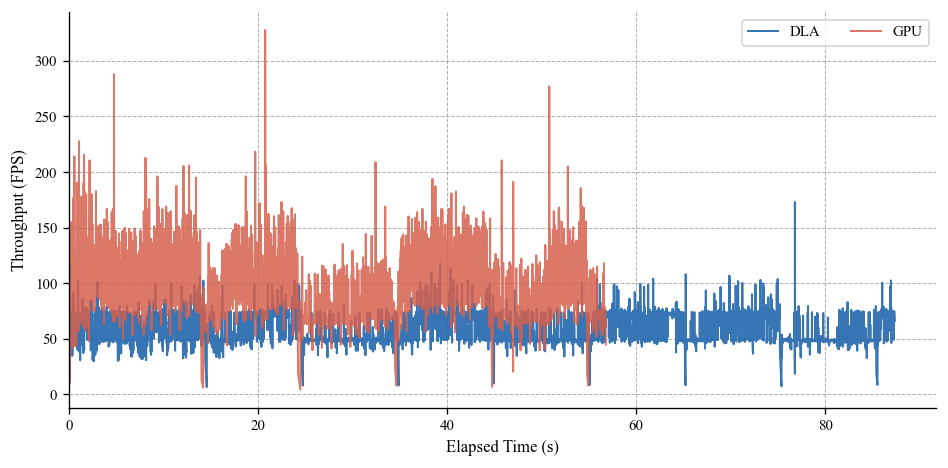

저장: latency_timeseries.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(dla["elapsed_s"], dla["fps"],
        color=COLOR_DLA, label="DLA", alpha=0.9)
ax.plot(gpu["elapsed_s"], gpu["fps"],
        color=COLOR_GPU, label="GPU", alpha=0.85)

# ax.axhline(avg_dla_fps, color=COLOR_DLA, ls="--", lw=1.0, alpha=0.7,
#            label=f"DLA mean: {avg_dla_fps:.2f} FPS")
# ax.axhline(avg_gpu_fps, color=COLOR_GPU, ls="--", lw=1.0, alpha=0.7,
#            label=f"GPU mean: {avg_gpu_fps:.2f} FPS")

# ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Throughput (FPS)")
#ax.set_title("Per-Image Inference Throughput — DLA vs GPU")
ax.set_xlim(left=0)
ax.grid(True, which="both")
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig("latency_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: latency_timeseries.png")

## FPS 분포 (히스토그램)

워밍업 첫 이미지를 제외한 안정 구간의 FPS 분포를 비교합니다.

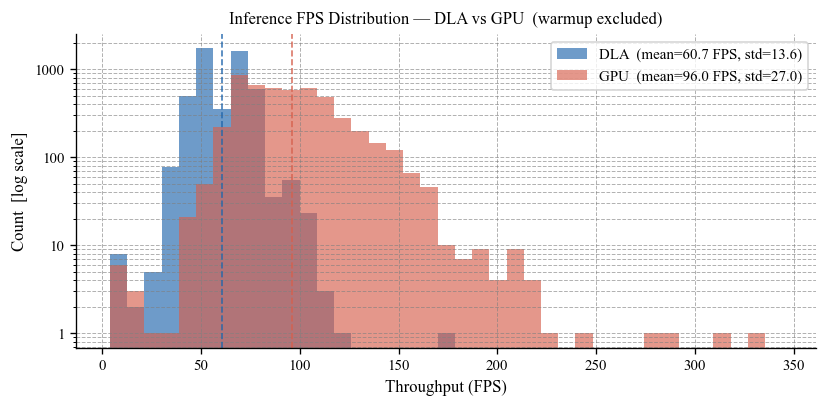

저장: latency_histogram.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))

fps_all = pd.concat([dla_stable["fps"], gpu_stable["fps"]])
bins = np.linspace(fps_all.min() * 0.95, fps_all.max() * 1.05, 40)

ax.hist(dla_stable["fps"], bins=bins, color=COLOR_DLA, alpha=0.65,
        label=f"DLA  (mean={avg_dla_fps:.1f} FPS, std={dla_stable['fps'].std():.1f})")
ax.hist(gpu_stable["fps"], bins=bins, color=COLOR_GPU, alpha=0.65,
        label=f"GPU  (mean={avg_gpu_fps:.1f} FPS, std={gpu_stable['fps'].std():.1f})")

ax.axvline(avg_dla_fps, color=COLOR_DLA, ls="--", lw=1.0, alpha=0.85)
ax.axvline(avg_gpu_fps, color=COLOR_GPU, ls="--", lw=1.0, alpha=0.85)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel("Throughput (FPS)")
ax.set_ylabel("Count  [log scale]")
ax.set_title("Inference FPS Distribution — DLA vs GPU  (warmup excluded)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
ax.grid(True, which="both")
ax.legend()
plt.tight_layout()
plt.savefig("latency_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: latency_histogram.png")